# Project Overview
Given the dataset people.csv, create a similarity measure between the people. Take in consideration that your resulting calculation could be used in a posterior data model.
- ID, Name, Surname and E-mail address do not matter for the measurement.
- Nulls in any record invalidates that record.
- Since Salary has a wide range, it requires some kind of treatment before use.
- You are free about how to treat Gender.
- Print the full name of the closest people in the dataset along with the measure you created.

# Import Libraries

In [2]:
# standard
import numpy as np
import pandas as pd
import time

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# other
from sklearn.datasets import load_iris

# Get Data

In [3]:
df = pd.read_csv('people.csv')

In [4]:
df.head()

,id,first_name,last_name,email,gender,salary,education,Married
0,1,Josi,Millson,jmillson0@youku.com,Female,$152647.10,PhD,False
1,2,Francyne,Rykert,frykert1@list-manage.com,Male,$187810.79,PhD,True
2,3,Fransisco,Muddimer,fmuddimer2@reuters.com,Female,$62980.35,MS,True
3,4,Katey,Chick,kchick3@blinklist.com,Female,$87550.97,MS,False
4,5,Sibelle,Molyneaux,smolyneaux4@nyu.edu,Male,$118699.14,BS,False


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 926 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          926 non-null    int64 
 1   first_name  926 non-null    object
 2   last_name   926 non-null    object
 3   email       926 non-null    object
 4   gender      926 non-null    object
 5   salary      926 non-null    object
 6   education   926 non-null    object
 7   Married     926 non-null    bool  
dtypes: bool(1), int64(1), object(6)
memory usage: 58.8+ KB


# Nulls in any record invalidates that record.

<Axes: >

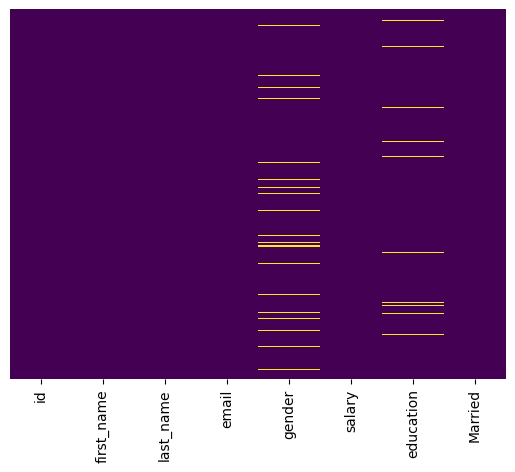

In [5]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [6]:
df.isnull().sum()

id             0
first_name     0
last_name      0
email          0
gender        52
salary         0
education     23
Married        0
dtype: int64

In [7]:
100* df.isnull().sum()/len(df)

id            0.0
first_name    0.0
last_name     0.0
email         0.0
gender        5.2
salary        0.0
education     2.3
Married       0.0
dtype: float64

In [8]:
df.dropna(inplace=True) 

In [9]:
100* df.isnull().sum()/len(df)

id            0.0
first_name    0.0
last_name     0.0
email         0.0
gender        0.0
salary        0.0
education     0.0
Married       0.0
dtype: float64

# EDA

## Gender

<Axes: xlabel='gender', ylabel='count'>

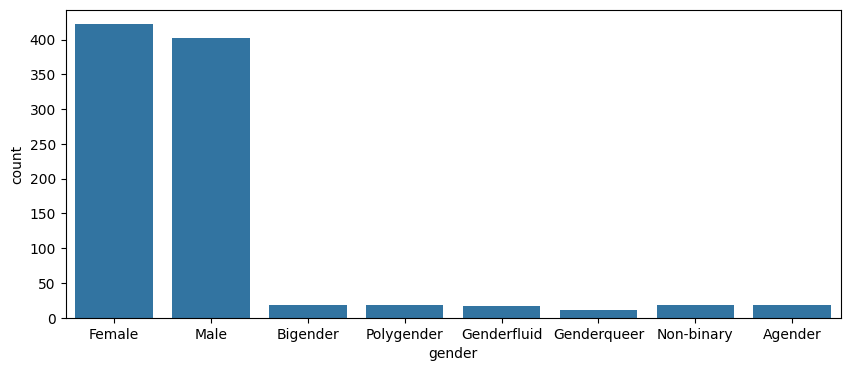

In [14]:
plt.figure(figsize=(10,4))
sns.countplot(x='gender',data=df)

In [17]:
gender_cant = df['gender'].value_counts()
gender_cant

gender
Female         422
Male           403
Non-binary      19
Bigender        18
Polygender      18
Agender         18
Genderfluid     17
Genderqueer     11
Name: count, dtype: int64

In [18]:
100* gender_cant/len(df)

gender
Female         45.572354
Male           43.520518
Non-binary      2.051836
Bigender        1.943844
Polygender      1.943844
Agender         1.943844
Genderfluid     1.835853
Genderqueer     1.187905
Name: count, dtype: float64

In [ ]:
# Si vemos que esas categorías que no son Female/Male son dificiles de predecir podemos agruparlas en una nueva variable 'gender_diverse'
#df.loc[~(df['gender'].isin(['Female','Male'])),'gender'] = 'gender_diverse'

## Education

<Axes: xlabel='education', ylabel='count'>

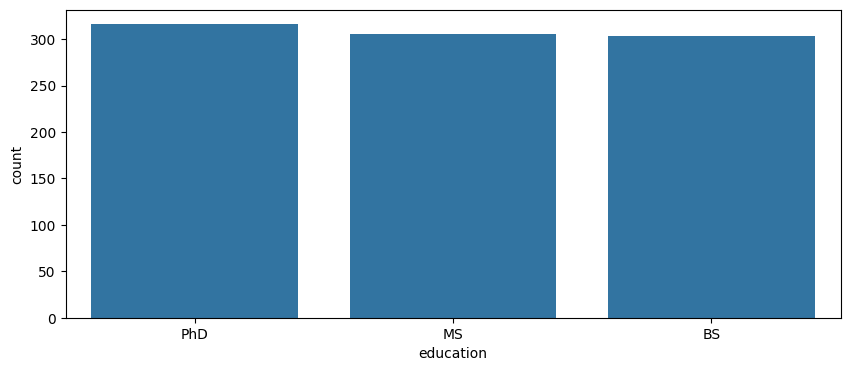

In [19]:
plt.figure(figsize=(10,4))
sns.countplot(x='education',data=df)

In [20]:
education_cant = df['education'].value_counts()
100* education_cant/len(df)

education
PhD    34.125270
MS     33.045356
BS     32.829374
Name: count, dtype: float64

## Married

<Axes: xlabel='Married', ylabel='count'>

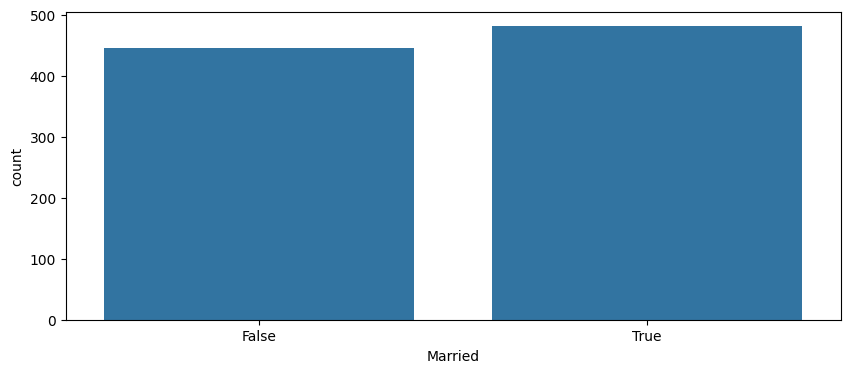

In [21]:
plt.figure(figsize=(10,4))
sns.countplot(x='Married',data=df)

In [22]:
married_cant = df['Married'].value_counts()
100* married_cant/len(df)

Married
True     51.943844
False    48.056156
Name: count, dtype: float64

## Salary

In [25]:
type(df['salary'].iloc[0])

str

In [26]:
# El salario está en 1 sola moneda?
df['salary'].str[:1].unique()

array(['$'], dtype=object)

In [27]:
# Como está en 1 sola moneda descarto el símbolo y lo paso a float
df['salary'] = df['salary'].str[1:].astype(float)

In [28]:
type(df['salary'].iloc[0])

numpy.float64

Text(0.5, 1.0, 'Histograma de salarios')

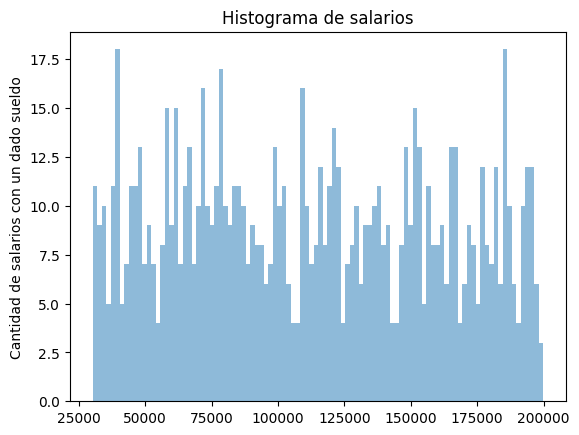

In [35]:
df['salary'].plot.hist(alpha=0.5,bins=100) 
plt.ylabel('Cantidad de salarios con un dado sueldo')
plt.title('Histograma de salarios')

/tmp/ipykernel_37237/2781017246.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['salary'],kde=True,bins=100)


<Axes: xlabel='salary', ylabel='Density'>

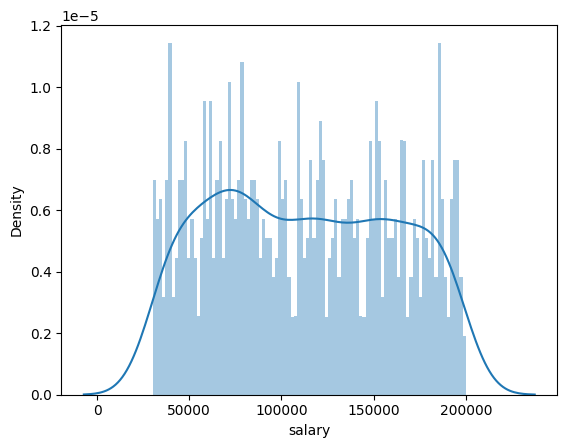

In [33]:
sns.distplot(df['salary'],kde=True,bins=100) 

# Since Salary has a wide range, it requires some kind of treatment before use.

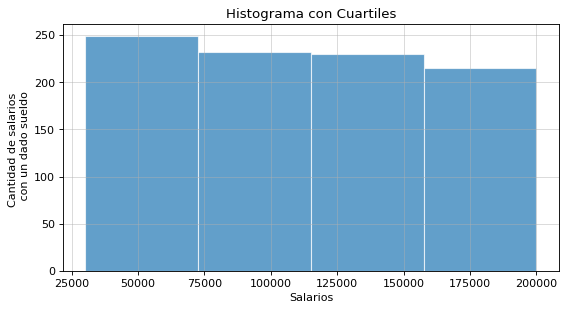

In [36]:
# Usaré cuartiles. La distribución queda bastante pareja, incluso los cuartiles 2 y 3 parecen indistinguibles.

quartiles = df['salary'].quantile([0.25, 0.5, 0.75])

plt.figure(figsize=(8,4), dpi=80)
plt.hist(df['salary'], bins=4, edgecolor='white', alpha=0.7)
plt.xlabel('Salarios')
plt.ylabel('Cantidad de salarios \n con un dado sueldo')
plt.title('Histograma con Cuartiles')
plt.grid(alpha=0.5)
plt.show()

In [37]:
df['salary_quartil'] = pd.qcut(df['salary'],
                                      q=np.arange(0,1.1,0.25),
                                      labels=np.arange(1,5,1))
df.head(3)

,id,first_name,last_name,email,gender,salary,education,Married,salary_quartil
0,1,Josi,Millson,jmillson0@youku.com,Female,152647.10,PhD,False,3
1,2,Francyne,Rykert,frykert1@list-manage.com,Male,187810.79,PhD,True,4
2,3,Fransisco,Muddimer,fmuddimer2@reuters.com,Female,62980.35,MS,True,1


También se podría haber empleado "Escalado o Normalización", que transforma los salarios para que estén en un rango más manejable, útil para algoritmos sensibles a la escala de los datos. Por ejemplo con Min-Max Scaling llevar todos los salarios entre 0 y 1.

# Similarity Measure

Métricas clásicas: Coseno, Euclidiana, Jaccard, etc.


Modelos basados en machine learning/deep learning: Siamese, embeddings, metric learning.


In [10]:
# Gender, salary, education, married

In [38]:
a

NameError: name 'a' is not defined